<a href="https://colab.research.google.com/github/arentfall/cosmological-constraints-imposed-by-SZE-and-X-ray-of-clusters/blob/main/SZ_Effect_and_X_ray%2C_ACDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importation

In [ ]:
# for Google Colab
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
!pip install emcee
!pip install corner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.8 MB/s eta 0:00:00


In [ ]:
# Import the various libraries

## Data manipulation
import pandas as pd               # Tables and operations on imported data
import seaborn as sns             # Statistical visualisation
from scipy.integrate import quad           # Compute a definite integral (from the Fortran library QUADPACK)
from scipy.special import beta               # Beta functions
import numpy as np
from astropy.cosmology import FlatLambdaCDM  # FLRW cosmology with a cosmological constant and no curvature is efficient for the MCMC
import emcee                          # Is needed to perform MCMC

## Visualisation
import matplotlib.pyplot as plt
import corner

In [ ]:
# Importing data from the data_isothermal.txt file
# Please note that the separator is a comma
df=pd.read_csv('data_isothermal.txt',
               sep=',')

##
T = df['Delta_T0 [mK]']                   # SZE decrement
uT_plus = df['u(Delta_T0)_+']         # Upper uncertainty
uT_minus = df['u(Delta_T0)_-']       # Lower uncertainty
#
z = df['z']                                       # Redshift
#
DA = df['DA [Gpc]']                         # Angular diameter distance
uDA_minus = df['u(DA)_-']
uDA_plus = df['u(DA)_+']
#
SX0 = df['S_X0 [cnt cm-2 arcmin-2]']       # X-ray surface brightness
uSX0_plus = df['u(S_X0)_+']
uSX0_minus = df['u(S_X0)_-']
#
kT = df['kT [keV]']                                   # Temperature of the hot gas
ukT_plus = df['u(kT)_+']
ukT_minus = df['u(kT)_-']
#
theta = df['theta_c [arcsec]']                    # Angular core radius
utheta_plus = df['u(theta_c)_+']
utheta_minus = df['u(theta_c)_-']
#
lambda0 = df['Lambda [cnt cm3 s-1]']      # X-ray cooling function
ulambda0_plus = df['u(Lambda)_+']
ulambda0_minus = df['u(Lambda)_-']

In [ ]:
df.describe()

,S_X0 [cnt cm-2 arcmin-2],u(S_X0)_+,u(S_X0)_-,theta_c [arcsec],u(theta_c)_+,u(theta_c)_-,Delta_T0 [mK],u(Delta_T0)_+,u(Delta_T0)_-,kT [keV],u(kT)_+,u(kT)_-,DA [Gpc],u(DA)_+,u(DA)_-,z,Lambda [cnt cm3 s-1],u(Lambda)_+,u(Lambda)_-
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000,38.00000,38.000000,38.000000,3.800000e+01,3.800000e+01,3.800000e+01
mean,146.823684,2.768421,2.771053,29.820789,1.545000,1.416053,-1.442105,0.156053,0.159737,8.539474,0.578947,0.526316,1.238421,0.36500,0.300000,0.390053,2.612368e-15,4.868421e-17,4.710526e-17
std,363.225691,5.414999,5.525954,20.642705,1.801825,1.472287,0.877201,0.096857,0.100981,2.380045,0.395350,0.323565,0.697740,0.27446,0.214047,0.216330,3.499145e-16,2.672898e-17,2.598418e-17
min,2.600000,0.100000,0.100000,3.590000,0.010000,0.010000,-5.150000,0.050000,0.060000,4.700000,0.100000,0.100000,0.420000,0.08000,0.070000,0.142000,1.810000e-15,1.000000e-17,1.000000e-17
25%,12.800000,0.400000,0.400000,13.125000,0.700000,0.625000,-1.672500,0.092500,0.100000,6.650000,0.300000,0.300000,0.760000,0.20000,0.170000,0.218750,2.352500e-15,3.000000e-17,3.000000e-17
50%,24.850000,0.950000,0.900000,22.200000,1.300000,1.250000,-1.230000,0.125000,0.130000,8.250000,0.500000,0.450000,1.075000,0.26500,0.225000,0.306500,2.665000e-15,4.500000e-17,4.000000e-17
75%,60.500000,1.650000,1.700000,43.200000,1.600000,1.500000,-0.892500,0.177500,0.177500,9.875000,0.675000,0.675000,1.480000,0.40750,0.337500,0.544750,2.880000e-15,6.750000e-17,6.000000e-17
max,1837.000000,30.000000,30.000000,70.400000,10.600000,8.400000,-0.460000,0.580000,0.600000,14.800000,2.000000,1.600000,3.650000,1.27000,0.990000,0.890000,3.140000e-15,1.100000e-16,1.100000e-16


# Analysis with Seaborn and simple plots

This section was mainly completed using the codes from Todorov's course in 'Artificial Intelligence', taken during the second semester of the Master's programme.

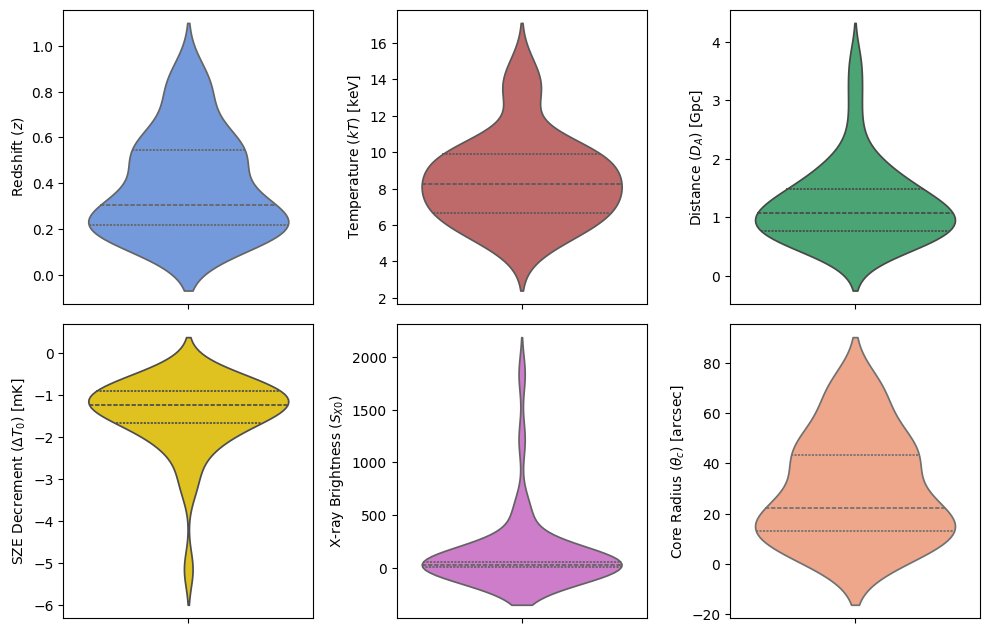

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(10, 7))

data_vars = [
    ('z', r'Redshift ($z$)', 'cornflowerblue'),
    ('kT [keV]', r'Temperature ($kT$) [keV]', 'indianred'),
    ('DA [Gpc]', r'Distance ($D_A$) [Gpc]', 'mediumseagreen'),
    ('Delta_T0 [mK]', r'SZE Decrement ($\Delta T_0$) [mK]', 'gold'),
    ('S_X0 [cnt cm-2 arcmin-2]', r'X-ray Brightness ($S_{X0}$)', 'orchid'),
    ('theta_c [arcsec]', r'Core Radius ($\theta_c$) [arcsec]', 'lightsalmon')
]

for i, (col, label, color) in enumerate(data_vars):
    ax = axes[i // 3, i % 3]
    sns.violinplot(y=df[col], ax=ax, color=color, inner="quartile")
    ax.set_ylabel(label, fontsize=10)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<Axes: xlabel='z'>

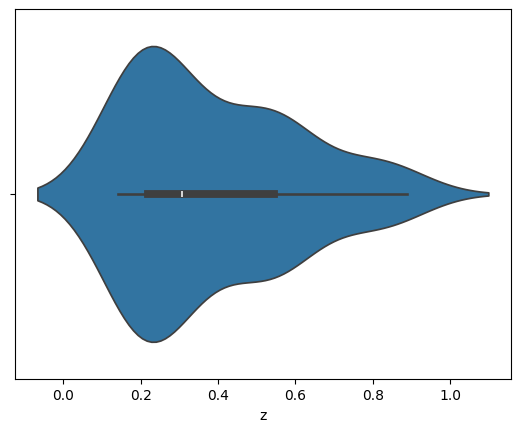

In [ ]:
sns.violinplot(x=z) # Densely concentrated between 0.2 and 0.6 (z < 3, permits to neglect Omega_k and Omega_r)

<Axes: xlabel='Delta_T0 [mK]'>

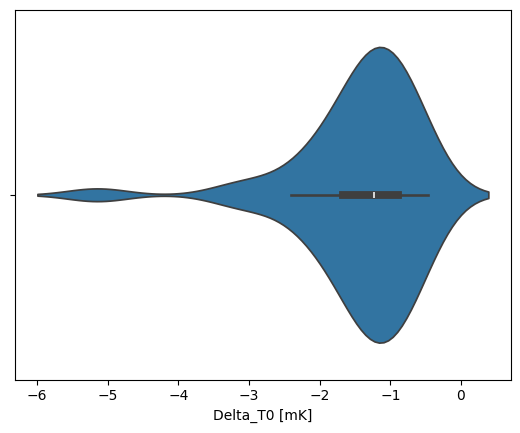

In [ ]:
sns.violinplot(x=T) # Skewed towards high values, heavily concentrated around -1 (as expected, Bonamente 2006)

<Axes: xlabel='DA [Gpc]'>

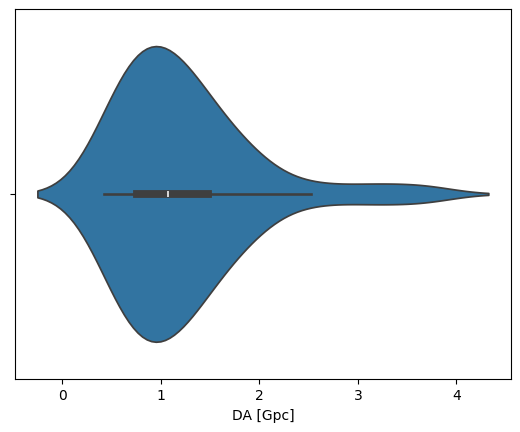

In [ ]:
sns.violinplot(x=DA)  # Concentration of clusters with distances around 1 Gpc, with a tail extending toward 4 Gpc

<Axes: xlabel='theta_c [arcsec]'>

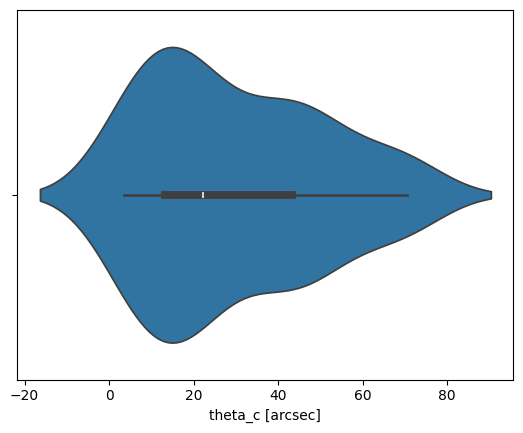

In [ ]:
sns.violinplot(x=theta)   # Peaks near 20 arcsec and spreads broadly up to 80-90 arcsec

<Axes: xlabel='S_X0 [cnt cm-2 arcmin-2]'>

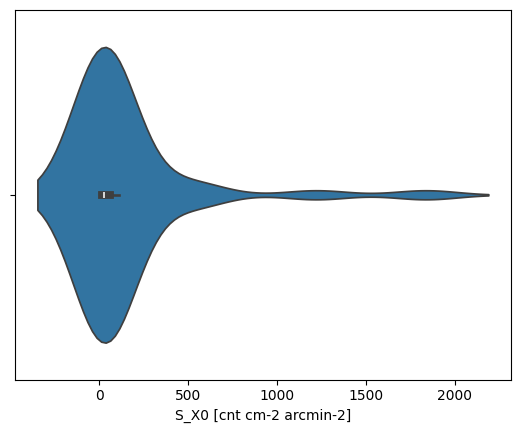

In [ ]:
sns.violinplot(x=SX0)  # Heavily skewed toward lower values, but with an extremely long tail extending past 2000
                                 # "Cool core" clusters have intense central spikes (concern 14 clusters, Bonamente 2006 ; interesting paper Hudson 2010 on this subject)
                                 # Dramatic variation in cluster core brightness

<Axes: xlabel='kT [keV]'>

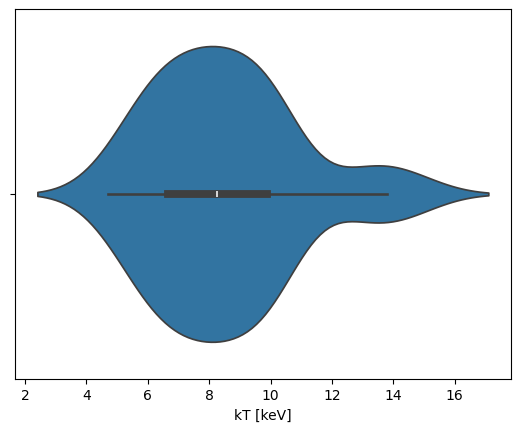

In [ ]:
sns.violinplot(x=kT)   # Temperatures largely clustered between 6 and 10 keV

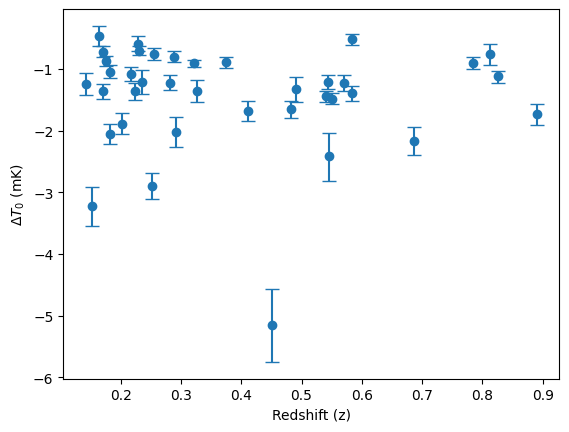

In [ ]:
## SZE decrement isn't quite affected by the redshift
plt.figure()
plt.errorbar(z, T, yerr=[uT_minus, uT_plus], fmt='o', capsize=5)
plt.xlabel('Redshift (z)')
plt.ylabel(r'$\Delta T_0$ (mK)')
plt.show()

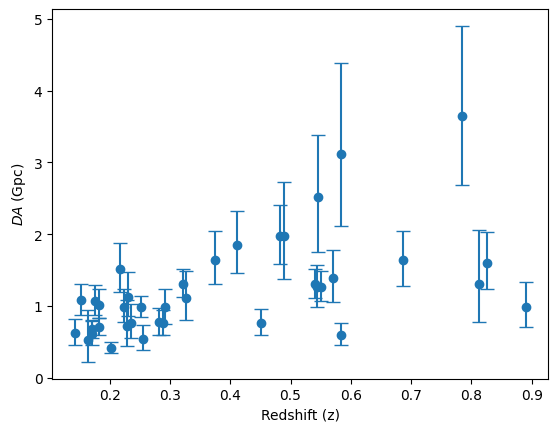

In [ ]:
# There is some dependency between DA and z
plt.figure()
plt.errorbar(z, DA, yerr=[uDA_minus, uDA_plus], fmt='o', capsize=5)
plt.xlabel('Redshift (z)')
plt.ylabel(r'$DA$ (Gpc)')
plt.show()

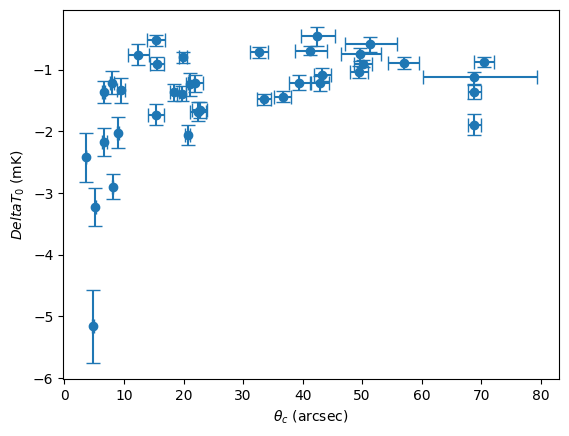

In [ ]:
# theta_c seems to be affected by the SZE decrement
plt.figure()
plt.errorbar(theta, T, xerr=[utheta_minus, utheta_plus], yerr=[uT_minus, uT_plus], fmt='o', capsize=5)
plt.xlabel(r'$\theta_c$ (arcsec)')
plt.ylabel(r'$Delta T_0$ (mK)')
plt.show()

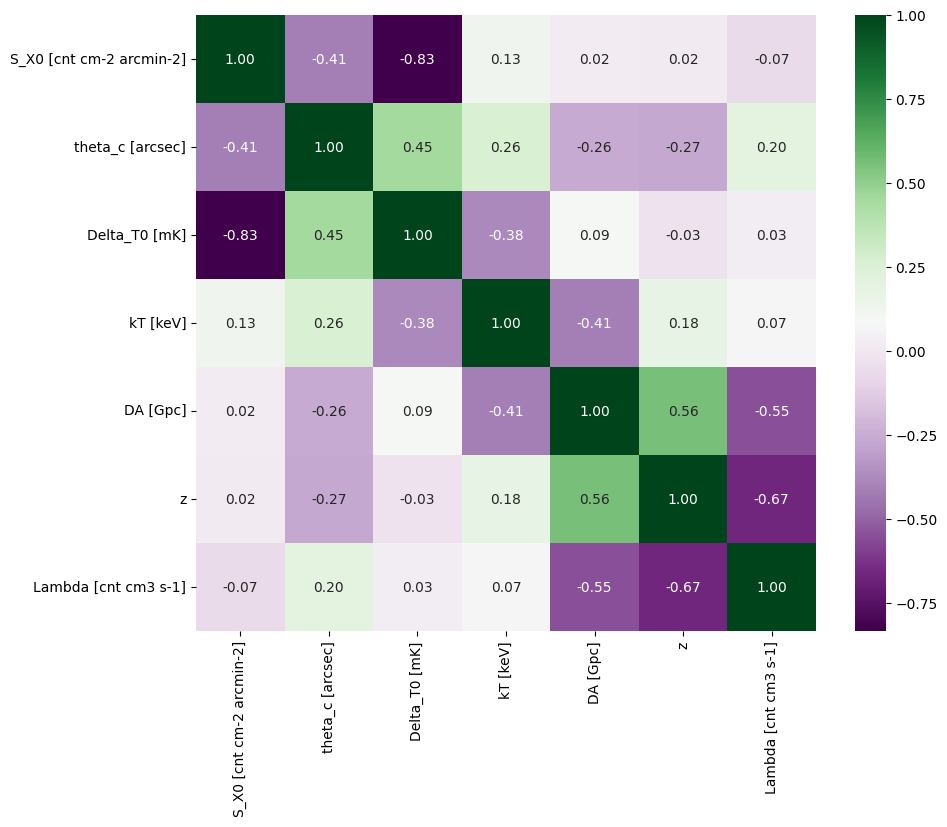

In [ ]:
## Selection of numerical columns
num_cols = df.select_dtypes(include=["float64"])

# Exclude columns that start with 'u(' (the uncertainty values)
num_cols = num_cols[[col for col in num_cols.columns if not col.startswith('u(')]]

# Calculation of the correlation matrix
corr_matrix = num_cols.corr()

# Displaying the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="PRGn",
            fmt=".2f")
plt.show()

# Strong correlation between SX0 and SZE (both impacted by the density of electron) ; z + DA and Lambda
# Mild correlation between theta and SZE (concentrated clusters may 'interact' more == produce more intense SZE) ;
 # theta and SX0 ; DA and z (Hubble flow, not higher than expected, this explains the use of MCMC in Bonamente 2006) ;
 # kT and DA + SZE

# Chi-squared test

Beginning of the chi-squared test to extract cosmological density values (mass and dark energy).

In [ ]:
c = 299792.458                                      # [km/s], the speed of light in vacuum
DA_err = (uDA_minus + uDA_plus) / 2    # Uncertainty mean, only statistical (Bonamente 2006)

## Combination of statistical contributions and systematic ones for the uncertainty (Table 3, Bonamente et al. 2006)
  # for the asphericity, the uncertainty can be up to 20 % (Puy et al. 2000) vs 15 % (Bonamente 2006)
DA_err_syst = (0.03 + 0.05 + 0.075 + 0.08 + 0.05) * DA.values
DA_err_total = np.sqrt(DA_err.values**2 + DA_err_syst**2)

  # Systematic Contributions (on DA, table 3): +3% Presence of radio halos, +5% X-ray absolute flux calibration (SX0),
  # +7.5% X-ray temperature calibration (kT), +8% SZE calibration

Reduced Chi2 = 0.99
Best Omega_m : 0.81 +/- 0.17
Min Chi2 : 36.68


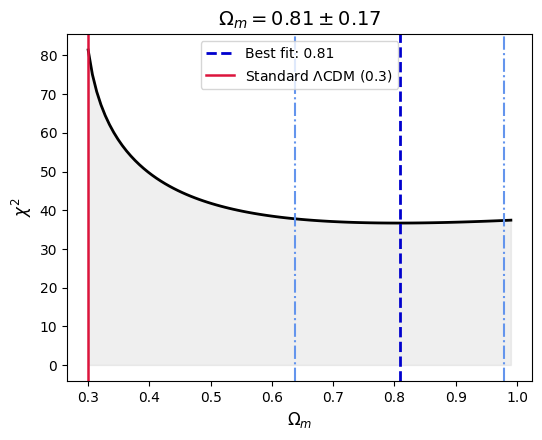

In [ ]:
H0 = 72.0 # Fixed value (Freedman et al. 2001) in km/s/Mpc

##
def theo_DA_Puy(z, omega_m): # the special case originally worked out by Mattig corresponding to a matter dominated universe, and for q0 > 0
                                               # in the paper "The Mattig Expression for a d-dimensional Gauss Bonnet FRWL Cosmology" ; Puy 2000
  q0 = 1.5 * omega_m - 1.0              # Deceleration parameter at the present epoch
  term_num = q0 * z + (q0 - 1.0) * (np.sqrt(1.0 + 2.0 * q0 * z) - 1.0)
  term_den = (q0**2) * ((1.0 + z)**2)
  da_theo = (c / H0) * (term_num / term_den)       # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def Chi2_Puy(omega_m, z_vals, DA_obs):
  DA_model = np.array(theo_DA_Puy(z_vals, omega_m))
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

##
omega_grid = np.linspace(0.30, 0.99, 100)             # Starting at 0.3 due to np.sqrt(1.0 + 2.0 * q0 * z) being null at below values
chi2_Puy_results = np.zeros_like(omega_grid)

for i, omega in enumerate(omega_grid):
  chi2 = Chi2_Puy(omega, z.values, DA.values)
  chi2_Puy_results[i] = chi2

best_idx = np.argmin(chi2_Puy_results)
best_om_Puy = omega_grid[best_idx]
min_chi2_Puy = chi2_Puy_results[best_idx]

limit_chi2_Puy = min_chi2_Puy + 1.0                     # Interval for 1 sigma / 68 % confidence interval
om_sigma_Puy = omega_grid[chi2_Puy_results <= limit_chi2_Puy]

om_min, om_max = om_sigma_Puy.min(), om_sigma_Puy.max()
uncertainty = (om_max - om_min) / 2

dof = len(z) - 1                                         # 1 parameter
chi2_red = min_chi2_Puy / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")    # If it is near 1, the model is correct
print(f"Best Omega_m : {best_om_Puy:.2f} +/- {uncertainty:.2f}")
print(f"Min Chi2 : {min_chi2_Puy:.2f}")

##
plt.figure(figsize=(6, 4.5))
plt.plot(omega_grid, chi2_Puy_results, color='black', lw=2)
plt.fill_between(omega_grid, chi2_Puy_results, color='dimgrey', alpha=0.1)

plt.axvline(best_om_Puy, color='mediumblue', linestyle='--', lw=2, label=f'Best fit: {best_om_Puy:.2f}')
plt.axvline(best_om_Puy - uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(best_om_Puy + uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(0.30, color='crimson', label=r'Standard $\Lambda$CDM (0.3)', lw=1.8)

plt.title(rf'$\Omega_m =  {best_om_Puy:.2f} \pm {uncertainty:.2f}$', fontsize=14)
plt.xlabel(r'$\Omega_m$', fontsize=12)
plt.ylabel(r'$\chi^2$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 1.52
Best H_0 : 96.97 +/- 6.67
Min Chi2 : 56.29


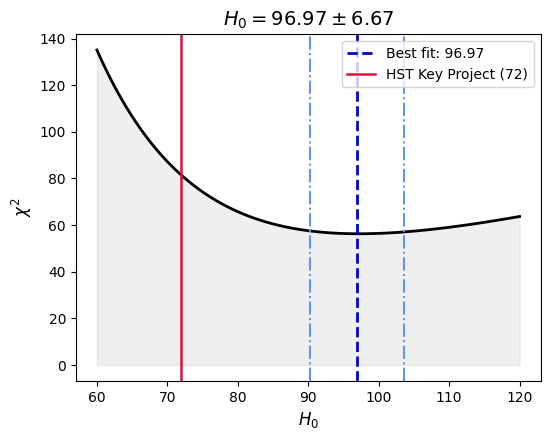

In [ ]:
##
def theo_DA_H0_Puy(z, H0):
  q0 = 1.50 * 0.30 - 1.00                                  # we impose Omega_m = 0.30
  term_num = q0 * z + (q0 - 1.0) * (np.sqrt(1.0 + 2.0 * q0 * z) - 1.0)
  term_den = (q0**2) * ((1.0 + z)**2)
  da_theo = (c / H0) * (term_num / term_den)   # [Mpc]
  return da_theo / 1000                                     # [Gpc]

def Chi2_H0_Puy(H0, z_vals, DA_obs):
  DA_model = np.array(theo_DA_H0_Puy(z_vals, H0))
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

##
H0_grid = np.linspace(60, 120, 100)
chi2_H0_Puy_results = np.zeros_like(H0_grid)

for i, H0 in enumerate(H0_grid):
  chi2 = Chi2_H0_Puy(H0, z.values, DA.values)
  chi2_H0_Puy_results[i] = chi2

best_idx = np.argmin(chi2_H0_Puy_results)
best_h0_Puy = H0_grid[best_idx]
min_chi2_Puy = chi2_H0_Puy_results[best_idx]

limit_chi2_Puy = min_chi2_Puy + 1.0                  # Interval for 1 sigma / 68 % confidence interval
oh_sigma_Puy = H0_grid[chi2_H0_Puy_results <= limit_chi2_Puy]

oh_min, oh_max = oh_sigma_Puy.min(), oh_sigma_Puy.max()
uncertainty = (oh_max - oh_min) / 2

dof = len(z) - 1                                         # 1 parameter
chi2_red = min_chi2_Puy / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct
print(f"Best H_0 : {best_h0_Puy:.2f} +/- {uncertainty:.2f}")
print(f"Min Chi2 : {min_chi2_Puy:.2f}")

##
plt.figure(figsize=(6, 4.5))
plt.plot(H0_grid, chi2_H0_Puy_results, color='black', lw=2)
plt.fill_between(H0_grid, chi2_H0_Puy_results, color='dimgrey', alpha=0.1)

plt.axvline(best_h0_Puy, color='mediumblue', linestyle='--', lw=2, label=f'Best fit: {best_h0_Puy:.2f}')
plt.axvline(best_h0_Puy - uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(best_h0_Puy + uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(72, color='crimson', label='HST Key Project (72)', lw=1.8)

plt.title(rf'$H_0 =  {best_h0_Puy:.2f} \pm {uncertainty:.2f}$', fontsize=14)
plt.xlabel(r'$H_0$', fontsize=12)
plt.ylabel(r'$\chi^2$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 0.98
Omega m = 0.63 +/- 0.29
Min Chi2 : 36.36


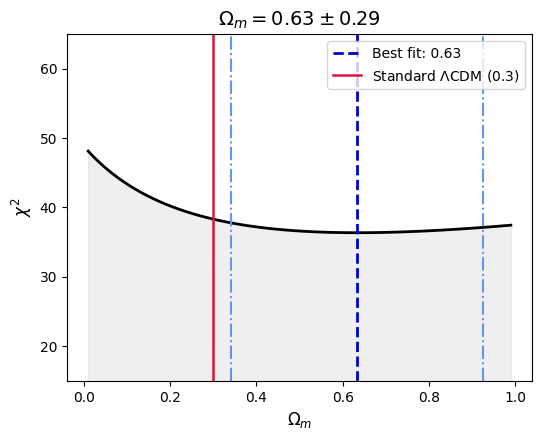

In [ ]:
H0 = 72                                          # Fixed value (Freedman et al. 2001) in km/s/Mpc

##
def theo_DA(z, omega_m):               # Bonamente 2006, LCDM model
  omega_lambda = 1 - omega_m
  integral = lambda zeta: 1 / np.sqrt(omega_m* (1+zeta)**3 + omega_lambda)
  term_num = c * quad(integral, 0, z)[0]   # Integration by the Scipy module quad
  term_den = H0 * (1+z)
  da_theo = (term_num / term_den)          # [Mpc]
  return da_theo / 1000                             # [Gpc]

def Chi2(omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA(zi, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

##
omega_grid = np.linspace(0.01, 0.99, 100)
chi2_results = np.zeros_like(omega_grid)

for i, omega in enumerate(omega_grid):
  chi2 = Chi2(omega, z.values, DA.values)
  chi2_results[i] = chi2

best_idx = np.argmin(chi2_results)
best_om = omega_grid[best_idx]
min_chi2 = chi2_results[best_idx]

limit_chi2 = min_chi2 + 1                         # interval for 1 sigma / 68 % confidence interval
om_sigma = omega_grid[chi2_results <= limit_chi2]

om_min, om_max = om_sigma.min(), om_sigma.max()
uncertainty = (om_max - om_min) / 2

dof = len(z) - 1                                         # 1 parameter
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct
print(f"Omega m = {best_om:.2f} +/- {uncertainty:.2f}")
print(f"Min Chi2 : {min_chi2:.2f}")

##
plt.figure(figsize=(6, 4.5))
plt.plot(omega_grid, chi2_results, color='black', lw=2)
plt.fill_between(omega_grid, chi2_results, color='dimgrey', alpha=0.1)

plt.axvline(best_om, color='mediumblue', linestyle='--', lw=2, label=f'Best fit: {best_om:.2f}')
plt.axvline(best_om - uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(best_om + uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(0.30, color='crimson', label=r'Standard $\Lambda$CDM (0.3)', lw=1.8)

plt.title(rf'$\Omega_m =  {best_om:.2f} \pm {uncertainty:.2f}$', fontsize=14)
plt.xlabel(r'$\Omega_m$', fontsize=12)
plt.ylabel(r'$\chi^2$', fontsize=12)

plt.ylim(15, 65)
plt.legend()
plt.show()

Reduced Chi2 = 1.02
H0 = 76.02 +/- 5.09 km/s/Mpc
Min Chi2 : 37.62


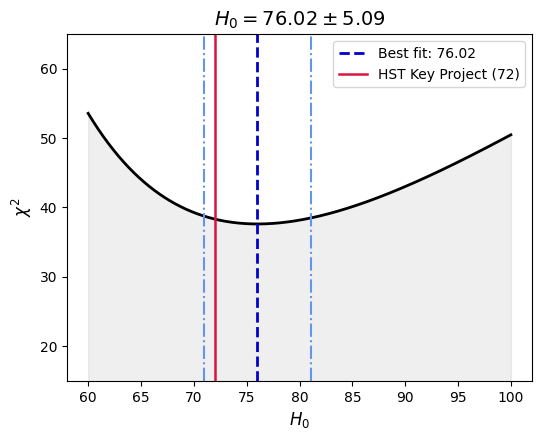

In [ ]:
##
def theo_DA_H0(z, H0):                          # LCDM model, Bonamente 2006
  omega_m = 0.30                                  # we impose Omega_m = 0.30
  omega_lambda = 1.00 - omega_m
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + omega_lambda)
  term_num = c * quad(integral, 0, z)[0]  # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)        # [Mpc]
  return da_theo / 1000                           # [Gpc]

def Chi2_H0(H0, z_vals, DA_obs):
  DA_model = np.array([theo_DA_H0(zi, H0) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

##
H0_grid = np.linspace(60, 100, 1000)
chi2_H0_results = np.zeros_like(H0_grid)

for i, H0 in enumerate(H0_grid):
  chi2 = Chi2_H0(H0, z.values, DA.values)
  chi2_H0_results[i] = chi2

best_idx = np.argmin(chi2_H0_results)
best_h0 = H0_grid[best_idx]
min_chi2_H0 = chi2_H0_results[best_idx]

limit_chi2 = min_chi2_H0 + 1.0                   # interval for 1 sigma / at 68% confidence
h0_sigma = H0_grid[chi2_H0_results <= limit_chi2]

h0_min, h0_max = h0_sigma.min(), h0_sigma.max()
uncertainty = (h0_max - h0_min) / 2

dof = len(z) - 1                                         # 1 parameter
chi2_red = min_chi2_H0 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct
print(f"H0 = {best_h0:.2f} +/- {uncertainty:.2f} km/s/Mpc")
print(f"Min Chi2 : {min_chi2_H0:.2f}")

##
plt.figure(figsize=(6, 4.5))
plt.plot(H0_grid, chi2_H0_results, color='black', lw=2)
plt.fill_between(H0_grid, chi2_H0_results, color='dimgrey', alpha=0.1)

plt.axvline(best_h0, color='mediumblue', linestyle='--', lw=2, label=f'Best fit: {best_h0:.2f}')
plt.axvline(best_h0 - uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(best_h0 + uncertainty, color='cornflowerblue', linestyle='-.')
plt.axvline(72, color='crimson', label='HST Key Project (72)', lw=1.8)

plt.title(rf'$H_0 =  {best_h0:.2f} \pm {uncertainty:.2f}$', fontsize=14)
plt.xlabel(r'$H_0$', fontsize=12)
plt.ylabel(r'$\chi^2$', fontsize=12)

plt.ylim(15, 65)
plt.legend()
plt.show()

# 2D Diagram

Reduced Chi2 = 1.01


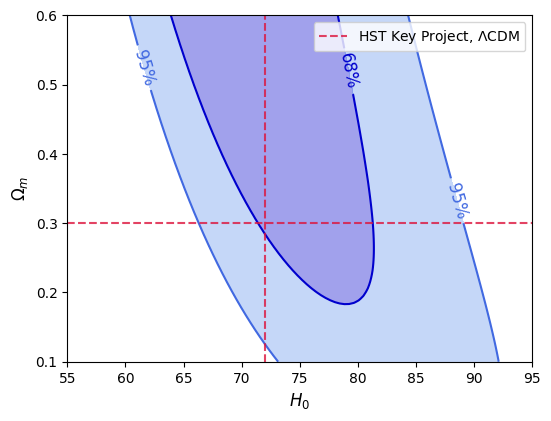

In [ ]:
## Confidence contour
om_range = np.linspace(0.1, 0.6, 100)
ho_range = np.linspace(55, 95, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA.values)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'HST Key Project, $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 0.98


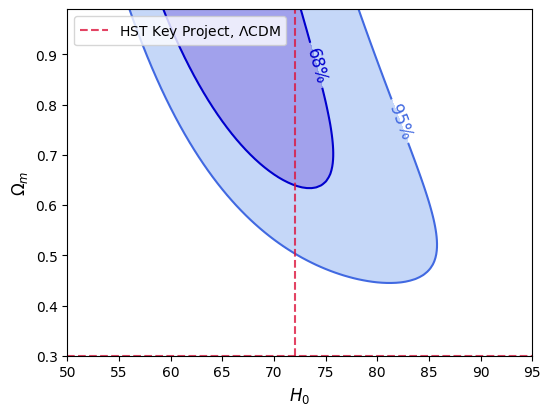

In [ ]:
## Confidence contour
om_range = np.linspace(0.30, 0.99, 100)
ho_range = np.linspace(50, 95, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_Puy_2D(z, H0, omega_m):
  q0 = 1.5 * omega_m - 1.0              # Deceleration parameter at the present epoch
  term_num = q0 * z + (q0 - 1.0) * (np.sqrt(1.0 + 2.0 * q0 * z) - 1.0)
  term_den = (q0**2) * ((1.0 + z)**2)
  da_theo = (c / H0) * (term_num / term_den)       # [Mpc]
  return da_theo / 1000                                         # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_Puy_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA.values)

##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'HST Key Project, $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

# DA verification

Verification of the DA values given in Table 5 (Bonamente 2006) using the measurement data (SX0, θc, β, ΔT0, kT and Λ) and equation (16) of Puy 2000, with θc = rc / DA.

In [ ]:
## Exposure times and beta values of the clusters
t_ks = np.array((67.4, 10.0, 7.4, 65.3, 42.2, 19.3, 10.0, 20.2, 36.1, 29.7, 19.5, 11.3, 46.0, 89.1,
                 77.0, 18.5, 9.7, 31.7, 14.9, 10.7, 57.7, 48.1, 19.5, 115.6, 18.9, 56.7, 10.3, 71.1, 8.6,
                 41.7, 51.7, 10.0, 9.1, 44.3, 8.5, 10.0, 19.5, 19.9))

beta_val = np.array((0.686, 0.721, 0.712, 0.768, 0.767, 0.645, 0.639, 0.516, 0.592, 0.536,
                     0.607, 0.613, 0.567, 1.045, 0.739, 0.633, 0.476, 0.701, 0.624, 0.554, 0.542,
                     0.483, 0.543, 0.550, 0.903, 0.918, 0.613, 0.576, 0.483, 0.766, 0.577,  0.579,
                     0.559,  0.639, 0.678, 0.507, 0.618, 0.532))

In [ ]:
##
h = 6.62607015e-34                                          # [kg.m2/s] = [J.s], Planck constant
kB = 1.380649e-23                                            # [kg.m2/s2/K] = [J/K], Boltzmann constant
nu = 30e9                                                         # [Hz], observing frequency (Bonamente 2006)
T_CMB = 2.728                                                  # [K], (Fixsen et al. 1996)
sigma = 6.6524587051e-29                                # [m2], Thomson cross section
me = 9.1e-31                                                    # [kg], electron mass
eps = 3.0e-28                                                    # [np2.J/m3/s], with np the proton number density (Puy 2000)
c_in_m = 299792458.0                                       # [m/s], the speed of the light in vacuum

# Conversions
arcmin_to_rad = np.pi  / (60*180)                        # [rad]
arcsec_to_rad = np.pi / (3600*180)                      # [rad]
keV_to_K = 11604525.0061657                            # [K]

w = (h * nu) / (kB * T_CMB)                                 # (Puy 2000)
fw = (w * (np.exp(w) + 1)) / (np.exp(w) - 1) - 4    # frequency dependence of the SZE (Puy 2000), approx - 2 (Bonamente 2006)

##
def verif_DA(z, T, SX0, Lambda0, kT, theta, t_ks, beta_val):     # (Puy 2000 and Bonamente 2006)
  beta_frac = beta(3*beta_val - 0.5, 0.5) / (beta(1.5*beta_val - 0.5, 0.5)**2)     # beta is the beta function from Scipy
  Lambda = Lambda0 * 1e-6                                 # [counts.m3/s]
  SX = (SX0 * 1e4) / (arcmin_to_rad**2)                 # [counts/m2/rad2]
  SX /= (t_ks * 1000)                                           # [counts/m2/s]
  T0 = kT * keV_to_K                                           # [K]
  thetac = theta * arcsec_to_rad                           # [rad]
  Delta_T = T * 1e-3                                             # [K]

  phys_term = ( (me * c_in_m**2) / (sigma * kB * T0) )**2
  cosmo_term = Lambda / (4 * np.pi * (1 + z)**4)
  y = (abs(Delta_T)) / (T_CMB * abs(fw))
  rc = (y**2 / SX) * phys_term * cosmo_term * beta_frac
  da = rc / thetac                                                  # [m]

  return da / 3.085677e25                                     # [Gpc]

##
DA_iso = verif_DA(z.values, T.values, SX0.values, lambda0.values, kT.values, theta.values, t_ks, 2/3)
DA_calc = verif_DA(z.values, T.values, SX0.values, lambda0.values, kT.values, theta.values, t_ks, beta_val)

print('Isothermal DA [Gpc]:', DA_iso)
print('')
print('Calculated DA [Gpc]:', DA_calc)

Isothermal DA [Gpc]: [0.86237482 0.40456193 0.88389952 0.89482304 0.58020532 0.19737558
 0.61021402 1.02383969 0.77408309 1.18539583 0.81500222 0.90329443
 1.19561968 0.46011156 1.72728579 0.45638657 0.79868547 0.47668615
 1.64692087 0.4871952  0.89316877 2.05447549 0.77961096 2.6027998
 0.26414316 0.55343508 0.72920658 0.47505481 1.94932737 0.74906737
 1.09683007 0.67412604 1.27426681 1.15651561 0.23600325 1.42301399
 0.84660817 2.51541496]

Calculated DA [Gpc]: [0.91188103 0.4686375  1.00125743 1.15279657 0.74590978 0.18439718
 0.55881407 0.52444792 0.59369796 0.68838565 0.66441972 0.75365498
 0.81893938 0.89597073 2.08808782 0.40945738 0.29843505 0.52489838
 1.43127211 0.31256504 0.53687819 0.81758195 0.47125952 1.63485497
 0.43045485 0.9214644  0.60840647 0.33952074 0.77573808 0.96097416
 0.78751112 0.48844444 0.83885704 1.05909924 0.24397912 0.68472279
 0.71976141 1.42647503]


In [ ]:
## Uncertainties of beta values
ubeta_val_plus = np.array((0.017, 0.035, 0.030, 0.029, 0.018, 0.012, 0.015, 0.008, 0.008, 0.008,
                     0.011, 0.010, 0.002, 0.213, 0.034, 0.015, 0.004, 0.041, 0.020, 0.003, 0.001,
                     0.003, 0.001, 0.001, 0.013, 0.024, 0.031, 0.006, 0.002, 0.014, 0.037,  0.021,
                     0.008,  0.033, 0.023, 0.005, 0.017, 0.011))

ubeta_val_minus = np.array((0.017, 0.029, 0.027, 0.027, 0.018, 0.012, 0.014, 0.007, 0.007, 0.008,
                     0.010, 0.010, 0.002, 0.146, 0.031, 0.014, 0.004, 0.036, 0.019, 0.003, 0.001,
                     0.003, 0.001, 0.001, 0.012, 0.023, 0.028, 0.005, 0.002, 0.012, 0.033,  0.018,
                     0.008,  0.029, 0.021, 0.005, 0.016, 0.011))

# Uncertainties on both calculated DA (un/perfect isothermal), symmetric error propagation
uDA_iso_plus = verif_DA(z.values, T + uT_plus.values, SX0 + uSX0_plus.values, lambda0 + ulambda0_plus.values,
                        kT + ukT_plus.values, theta + utheta_plus.values, t_ks, 2/3)
uDA_iso_minus = verif_DA(z.values, T + uT_minus.values, SX0 + uSX0_minus.values, lambda0 + ulambda0_minus.values,
                         kT + ukT_minus.values, theta + utheta_minus.values, t_ks, 2/3)

uDA_calc_plus = verif_DA(z.values, T + uT_plus.values, SX0 + uSX0_plus.values, lambda0 + ulambda0_plus.values,
                        kT + ukT_plus.values, theta + utheta_plus.values, t_ks, beta_val + ubeta_val_plus)
uDA_calc_minus = verif_DA(z.values, T + uT_minus.values, SX0 + uSX0_minus.values, lambda0 + ulambda0_minus.values,
                         kT + ukT_minus.values, theta + utheta_minus.values, t_ks, beta_val + ubeta_val_minus)

#
DA_iso_err = abs( (uDA_iso_plus + uDA_iso_minus) / 2 - DA_iso )
DA_calc_err = abs( (uDA_calc_plus + uDA_calc_minus) / 2 - DA_calc )

In [ ]:
# Monte Carlo approach
N = 2000
DA_samples = np.zeros((N, len(z)))
DA_samples_iso = np.zeros((N, len(z)))

for i in range(N):
    T_s = np.random.normal(T, (uT_plus + uT_minus)/2)
    SX_s = np.random.normal(SX0, (uSX0_plus + uSX0_minus)/2)
    kT_s = np.random.normal(kT, (ukT_plus + ukT_minus)/2)
    theta_s = np.random.normal(theta, (utheta_plus + utheta_minus)/2)
    beta_s = np.random.normal(beta_val, (ubeta_val_plus + ubeta_val_minus)/2)

    DA_samples[i] = verif_DA(z, T_s, SX_s, lambda0, kT_s, theta_s, t_ks, beta_s)
    DA_samples_iso[i] = verif_DA(z, T_s, SX_s, lambda0, kT_s, theta_s, t_ks, 2/3)

# Final uncertainties
DA_calc_std = np.std(DA_samples, axis=0)
DA_iso_std = np.std(DA_samples_iso, axis=0)

In [ ]:
## Comparison of the Monte Carlo method and symmetric error propagation (DA_calc, then DA_iso in next cell)
ratio = DA_calc_err / DA_calc_std

print("Ratio per cluster: \n", ratio)           # Big deviation per cluster reflects the non-linear dependency of DA
print("")
print(f"Mean ratio: {ratio.mean():.3f}")    # On average, symmetric error propagation slightly overestimates uncertainties

Ratio per cluster: 
 0     1.163678
1     0.992748
2     0.995633
3     1.037134
4     1.193691
5     1.088640
6     1.114230
7     1.177133
8     1.142627
9     1.041446
10    1.141281
11    1.112165
12    1.041061
13    0.718657
14    1.021507
15    1.149642
16    1.021790
17    0.876286
18    1.046058
19    1.267134
20    1.211018
21    1.118938
22    1.224416
23    0.985689
24    1.130430
25    1.226390
26    0.883638
27    1.078597
28    1.163296
29    1.190929
30    0.770633
31    0.775881
32    1.164503
33    0.944008
34    1.082088
35    1.091860
36    1.128732
37    1.119496
dtype: float64

Mean ratio: 1.069


In [ ]:
# It's much more pronounced for DA_iso
ratio = DA_iso_err / DA_iso_std

print("Ratio per cluster: \n", ratio)
print("")
print(f"Mean ratio: {ratio.mean():.3f}")

Ratio per cluster: 
 0     1.442513
1     1.133655
2     1.164156
3     1.229089
4     1.353973
5     1.182314
6     1.236821
7     1.304168
8     1.246147
9     1.239081
10    1.275193
11    1.224804
12    1.071431
13    1.165764
14    1.203660
15    1.308654
16    1.102502
17    1.038186
18    1.156449
19    1.344114
20    1.228363
21    1.174169
22    1.253983
23    0.995858
24    1.209527
25    1.414248
26    1.018116
27    1.194539
28    1.231899
29    1.296451
30    0.878798
31    0.829841
32    1.304352
33    1.075956
34    1.254947
35    1.160581
36    1.341255
37    1.304868
dtype: float64

Mean ratio: 1.200


# Anomaly/Borderline threshold per cluster for each calculated DA

We want to qualitatively compare our results to DA of the Table 5.

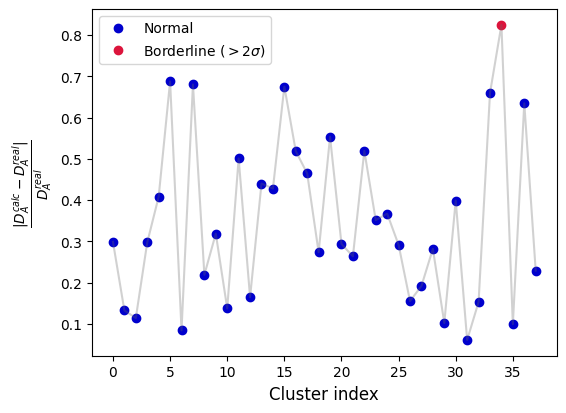

Abnormal peak for cluster index 34:
  Difference: 0.82 Gpc
  Threshold:  0.78 Gpc



In [ ]:
## Same for DA_calc vs DA_real (Table 5, Bonamente 2006)
sigma_diff = np.sqrt(DA_calc_std**2 + DA_err_total**2)
thres_DA = 2 * sigma_diff / DA

diff_DA = np.abs(DA_calc - DA) / DA
indices = np.arange(len(diff_DA))

mask_anomaly_calc = diff_DA >= thres_DA
mask_normal = diff_DA < thres_DA

#
plt.figure(figsize=(6, 4.5))

plt.plot(indices[mask_normal], diff_DA[mask_normal], 'o', color='mediumblue', label='Normal')
plt.plot(indices[mask_anomaly_calc], diff_DA[mask_anomaly_calc], 'o', color='crimson', label=r'Borderline ($>2\sigma$)')
plt.plot(indices, diff_DA, color='dimgrey', linestyle='-', alpha=0.3)

plt.ylabel(r"$\frac{|D_A^{calc} - D_A^{real}|}{D_A^{real}}$", fontsize=14)
plt.xlabel('Cluster index', fontsize=12)
plt.legend()
plt.show()
#
for i in indices[mask_anomaly_calc]:                            # More of a borderline fluctuation (not > 3)
        print(f'Abnormal peak for cluster index {i}:')
        print(f'  Difference: {diff_DA[i]:.2f} Gpc')
        print(f'  Threshold:  {thres_DA[i]:.2f} Gpc\n')

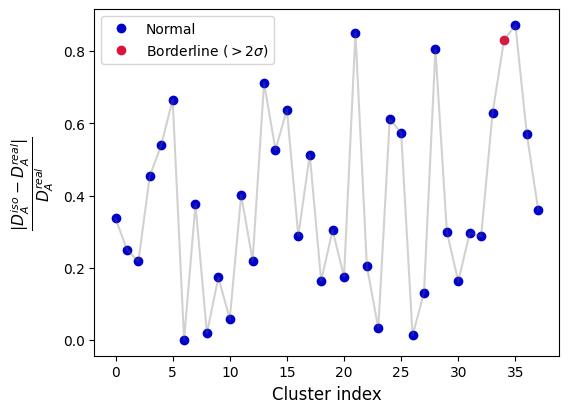

Abnormal peak for cluster index 34:
  Difference: 0.83 Gpc
  Threshold:  0.78 Gpc



In [ ]:
## Same for DA_iso vs DA_real (Table 5, Bonamente 2006)
sigma_diff = np.sqrt(DA_iso_std**2 + DA_err_total**2)
thres_DA = 2.0 * sigma_diff / DA

diff_DA = np.abs(DA_iso - DA) / DA
indices = np.arange(len(diff_DA))

mask_anomaly_iso = diff_DA >= thres_DA
mask_normal = diff_DA < thres_DA

#
plt.figure(figsize=(6, 4.5))

plt.plot(indices[mask_normal], diff_DA[mask_normal], 'o', color='mediumblue', label='Normal')
plt.plot(indices[mask_anomaly_iso], diff_DA[mask_anomaly_iso], 'o', color='crimson', label=r'Borderline ($>2\sigma$)')
plt.plot(indices, diff_DA, color='dimgrey', linestyle='-', alpha=0.3)

plt.ylabel(r"$\frac{|D_A^{iso} - D_A^{real}|}{D_A^{real}}$", fontsize=16)
plt.xlabel('Cluster index', fontsize=12)
plt.legend()
plt.show()
#
for i in indices[mask_anomaly_iso]:                             # More of a borderline fluctuation (not > 3)
        print(f'Abnormal peak for cluster index {i}:')
        print(f'  Difference: {diff_DA[i]:.2f} Gpc')
        print(f'  Threshold:  {thres_DA[i]:.2f} Gpc\n')

Those high blue points simply represent measurements for which we lack the precision to claim that an anomaly exists, despite the significant difference in value. This is due to their higher uncertainties compared to the 35th cluster (MACS J2129.4-0741).

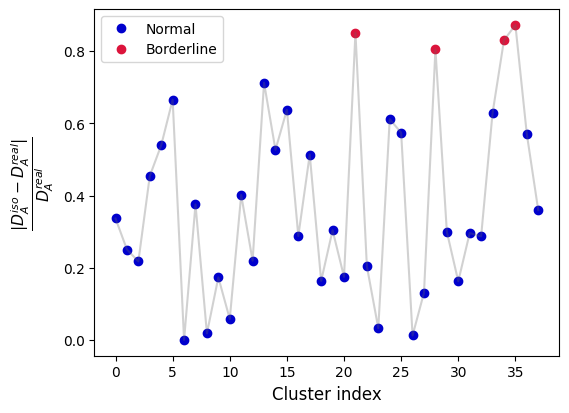

Abnormal peak for cluster index 21:
  Difference: 0.85 Gpc
Abnormal peak for cluster index 28:
  Difference: 0.80 Gpc
Abnormal peak for cluster index 34:
  Difference: 0.83 Gpc
Abnormal peak for cluster index 35:
  Difference: 0.87 Gpc


In [ ]:
## Same for DA_iso vs DA_real (Table 5, Bonamente 2006)
diff_DA = np.abs(DA_iso - DA) / DA
indices = np.arange(len(diff_DA))

mask_borderline_iso = diff_DA >= 0.8
mask_normal = diff_DA < 0.8

#
plt.figure(figsize=(6, 4.5))

plt.plot(indices[mask_normal], diff_DA[mask_normal], 'o', color='mediumblue', label='Normal')
plt.plot(indices[mask_borderline_iso], diff_DA[mask_borderline_iso], 'o', color='crimson', label=r'Borderline')
plt.plot(indices, diff_DA, color='dimgrey', linestyle='-', alpha=0.3)

plt.ylabel(r"$\frac{|D_A^{iso} - D_A^{real}|}{D_A^{real}}$", fontsize=16)
plt.xlabel('Cluster index', fontsize=12)
plt.legend()
plt.show()
#
for i in indices[mask_borderline_iso]:
        print(f'Abnormal peak for cluster index {i}:')
        print(f'  Difference: {diff_DA[i]:.2f} Gpc')

# Study of the 35th Cluster (MACS J2129.4-0741) case




We want to search wich parameter drives the discrepancy.

In [ ]:
index_cluster = 34

z_i = z.values[index_cluster]
T_i = T.values[index_cluster]
SX0_i = SX0.values[index_cluster]
Lambda0_i = lambda0.values[index_cluster]
kT_i = kT.values[index_cluster]
theta_i = theta.values[index_cluster]
beta_i = beta_val[index_cluster]
da_i = DA_calc[index_cluster]

print("Cluster of index 34:")
print("z =", z_i)
print("Delta T =", T_i)
print("SX0 =", SX0_i)
print("Lambda0 =", Lambda0_i)
print("kT =", kT_i)
print("theta =", theta_i)
print("beta =", beta_i)
print("Calculated DA =", f'{da_i:.3f}')

Cluster of index 34:
z = 0.57
Delta T = -1.22
SX0 = 21.9
Lambda0 = 2.72e-15
kT = 8.6
theta = 22.0
beta = 0.678
Calculated DA = 0.244


In [ ]:
d = 0.05

DA_kT_up = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i*(1+d), theta_i,t_ks[i], beta_i)
DA_kT_down = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i*(1-d), theta_i, t_ks[i], beta_i)

print("ΔDA from kT:", (DA_kT_up - DA_kT_down)/2)

DA_T_up = verif_DA(z_i, T_i*(1+d), SX0_i, Lambda0_i, kT_i, theta_i,t_ks[i], beta_i)
DA_T_down = verif_DA(z_i, T_i*(1-d), SX0_i, Lambda0_i, kT_i, theta_i, t_ks[i], beta_i)

print("ΔDA from Delta T:", (DA_T_up - DA_T_down)/2)

DA_SX0_up = verif_DA(z_i, T_i, SX0_i*(1+d), Lambda0_i, kT_i, theta_i,t_ks[i], beta_i)
DA_SX0_down = verif_DA(z_i, T_i, SX0_i*(1-d), Lambda0_i, kT_i, theta_i, t_ks[i], beta_i)

print("ΔDA from SX0:", (DA_SX0_up - DA_SX0_down)/2)

DA_Lambda0_up = verif_DA(z_i, T_i, SX0_i, Lambda0_i*(1+d), kT_i, theta_i,t_ks[i], beta_i)
DA_Lambda0_down = verif_DA(z_i, T_i, SX0_i, Lambda0_i*(1-d), kT_i, theta_i, t_ks[i], beta_i)

print("ΔDA from Lambda0:", (DA_Lambda0_up - DA_Lambda0_down)/2)

DA_theta_up = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i, theta_i*(1+d),t_ks[i], beta_i)
DA_theta_down = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i, theta_i*(1-d), t_ks[i], beta_i)

print("ΔDA from theta:", (DA_theta_up - DA_theta_down)/2)

DA_beta_up = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i, theta_i,t_ks[i], beta_i*(1+d))
DA_beta_down = verif_DA(z_i, T_i, SX0_i, Lambda0_i, kT_i, theta_i, t_ks[i], beta_i*(1-d))

print("ΔDA from beta:", (DA_beta_up - DA_beta_down)/2)

ΔDA from kT: -0.028847482724440654
ΔDA from Delta T: 0.02870342560758546
ΔDA from SX0: -0.014387682008814767
ΔDA from Lambda0: 0.014351712803792771
ΔDA from theta: -0.014387682008814795
ΔDA from beta: 0.027904754299136414


A sensitivity analysis shows that the discrepancy is primarily driven by temperature, SZ decrement, and β-model parameters.

# 2D Diagrams with calculated DA

In [ ]:
## Using statistical uncertainties alone leads to a reduced χ² = 6.85 (iso), 7.10 (calc), indicating underestimated errors
  # Every source of uncertainty needs to be incorporated
stat_pcts = np.array([0.01, 0.15, 0.08, 0.08, 0.01, 0.02]) # NH, asphericity, point sources, kinetic SZE, CMB, background
syst_pcts = np.array([0.03, 0.05, 0.075, 0.08]) # Radio halos, X-ray flux, T calibration, SZE calibration
err_pct_sq = np.sum(stat_pcts**2) + np.sum(syst_pcts**2)
DA_iso_err_tot = np.sqrt(DA_iso_std**2 + (err_pct_sq * DA_iso**2))
DA_calc_err_tot = np.sqrt(DA_calc_std**2 + (err_pct_sq * DA_calc**2))

Reduced Chi2 = 3.97


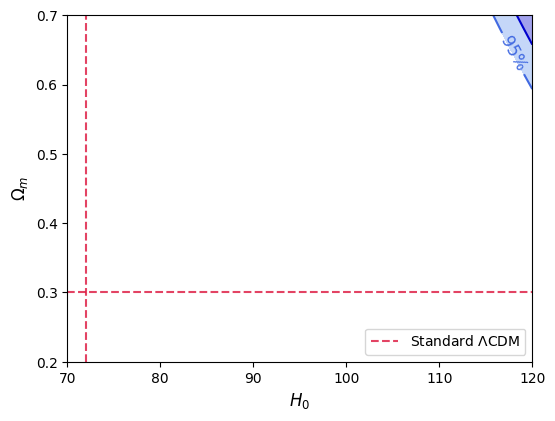

In [ ]:
## Confidence contour of DA_iso
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_iso_err_tot**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_iso)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 3.27


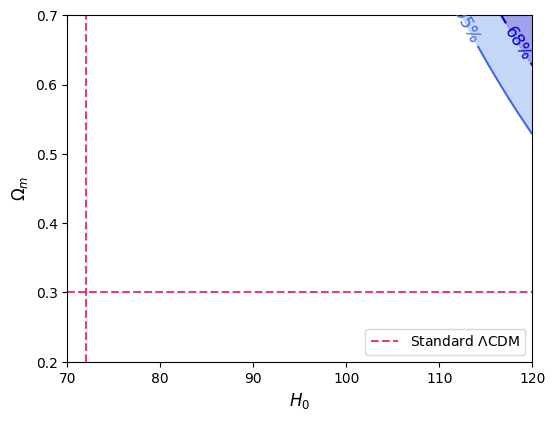

In [ ]:
DA_iso_2D = np.copy(DA_iso)
DA_iso_2D_err = np.copy(DA_iso_err_tot)

for i in indices[mask_anomaly_iso]:
  DA_iso_2D[i] = DA[i]
  DA_iso_2D_err[i] = DA_err_total[i]

## Confidence contour of DA_iso with the cluster 34 replaced
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_iso_2D_err**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_iso_2D)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 3.07


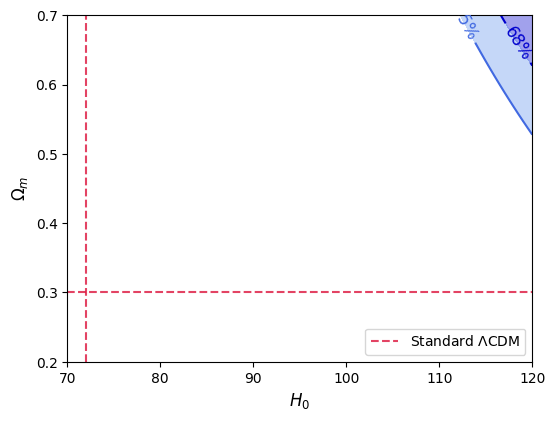

In [ ]:
DA_iso_normal = np.copy(DA_iso)
DA_iso_normal_err = np.copy(DA_iso_err_tot)

for i in indices[mask_borderline_iso]:
  DA_iso_normal[i] = DA[i]
  DA_iso_normal_err[i] = DA_err_total[i]

## Confidence contour of DA_iso with all borderline clusters replaced (beyond or equal to a difference of 0.8 compared to DA)
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_iso_normal_err**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_iso_normal)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 1.32


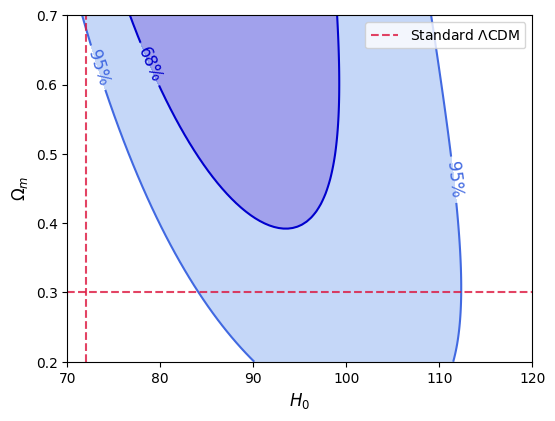

In [ ]:
## Confidence contour of DA_iso_normal with the uncertainty of DA_real
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_iso_normal)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 3.40


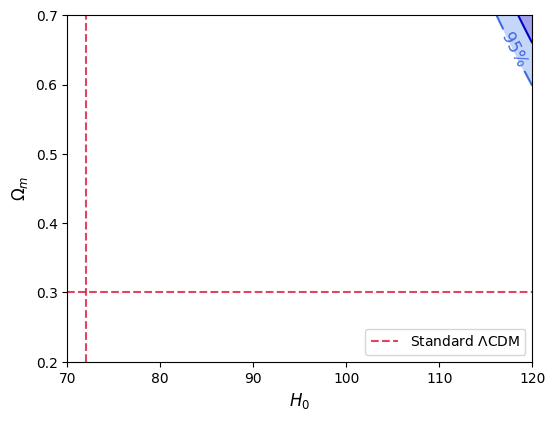

In [ ]:
## Confidence contour of DA_calc
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_calc_err_tot**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_calc)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 2.80


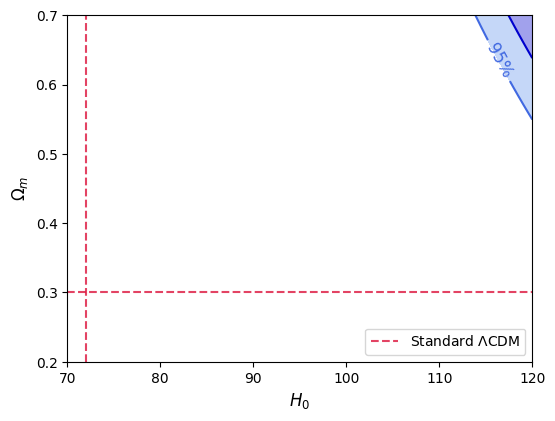

In [ ]:
DA_calc_2D = np.copy(DA_calc)
DA_calc_2D_err = np.copy(DA_calc_err_tot)
for i in indices[mask_anomaly_calc]:
  DA_calc_2D[i] = DA[i]
  DA_calc_2D_err[i] = DA_err_total[i]

## Confidence contour of DA_calc with the cluster 34 replaced
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_calc_2D_err**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_calc_2D)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

Reduced Chi2 = 0.69


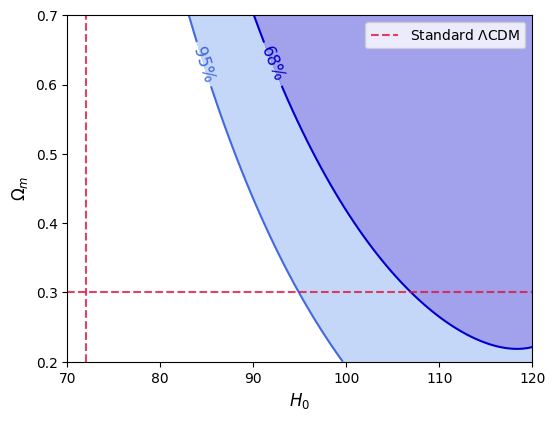

In [ ]:
## Confidence contour of DA_calc_2D with the uncertainty of DA_real
om_range = np.linspace(0.2, 0.7, 100)
ho_range = np.linspace(70, 120, 100)
OM, HO = np.meshgrid(om_range, ho_range)

##
def theo_DA_2D(z, H0, omega_m):             # LCDM model, Bonamente 2006
  integral = lambda zeta: 1.0 / np.sqrt(omega_m * (1.0+zeta)**3 + (1.0 - omega_m))
  term_num = c * quad(integral, 0, z)[0]      # Integration by the Scipy module quad
  term_den = H0 * (1.0+z)
  da_theo = (term_num / term_den)             # [Mpc]
  return da_theo / 1000                                # [Gpc]

def Chi2_2D(H0, omega_m, z_vals, DA_obs):
  DA_model = np.array([theo_DA_2D(zi, H0, omega_m) for zi in z_vals])
  chi2 = np.sum((DA_obs - DA_model)**2 / DA_err_total**2)
  return chi2

chi2_2d = np.zeros_like(OM)
for i in range(len(ho_range)):
    for j in range(len(om_range)):
        chi2_2d[i, j] = Chi2_2D(HO[i, j], OM[i, j], z.values, DA_calc_2D)
##
plt.figure(figsize=(6, 4.5))
min_chi2 = np.min(chi2_2d)
delta_chi2 = chi2_2d - min_chi2

dof = len(z) - 2                                         # 2 parameters
chi2_red = min_chi2 / dof

print(f"Reduced Chi2 = {chi2_red:.2f}")      # If it is near 1, the model is correct

plt.contourf(HO, OM, delta_chi2,
                       levels=[0, 2.30, 6.17],               # sigma 1 / 68 % ; sigma 2 / 95 %
                       colors=['mediumblue', 'cornflowerblue'], alpha=0.37)

contours = plt.contour(HO, OM, delta_chi2, levels=[2.30, 6.17],
                       colors=['mediumblue', 'royalblue'], linewidths=1.5)

plt.axvline(72, color='crimson', linestyle='--', alpha=0.8, label=r'Standard $\Lambda$CDM')
plt.axhline(0.3, color='crimson', linestyle='--', alpha=0.8)

plt.clabel(contours, inline=True, fmt={2.30: '68%', 6.17: '95%'}, fontsize=12)
plt.xlabel(r'$H_0$ ', fontsize=12)
plt.ylabel(r'$\Omega_m$', fontsize=12)

plt.legend()
plt.show()

This is a common 'growing pain' in this analysis. As Wan et al. (2021) noted, the primary systematic limitation is the X-ray temperature calibration, which currently has an uncertainty of 13% and effectively doubles the uncertainty on H0 to 26%.

In [ ]:
# Save the diameter distances
np.savez_compressed("reconstructed_DA", DA_iso_normal, DA_calc_2D)
print("Arrays saved!")

Arrays saved!


# MCMCs

100%|██████████| 5000/5000 [22:29<00:00,  3.71it/s]


H0 = 70.55 +/- [-6.22450984  7.0266713 ]
Omega_m = 0.46 +/- [-0.22734533  0.17195896]
sigma_int = 0.17 +/- [-0.08070966  0.08313934]


<Figure size 800x800 with 0 Axes>

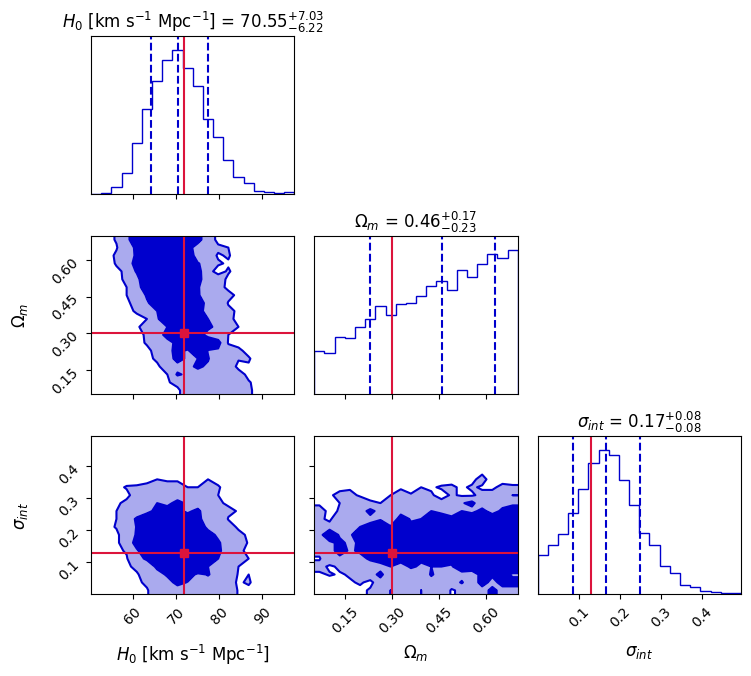

<Figure size 640x480 with 0 Axes>

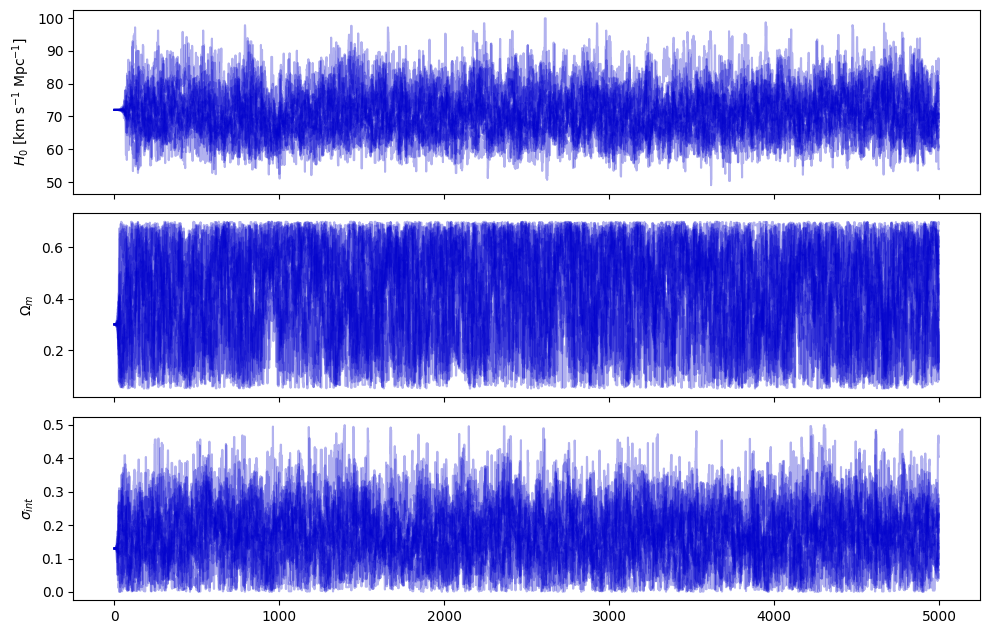

Autocorrelation times: [50.92515573 54.43840998 38.2288968 ]


In [ ]:
def lnlike(theta, z_vals, DA_obs, DA_err):
    H0, omega_m, sigma_int = theta                       # Parameters taken by the emcee for the MCMC, we add sigma_int to incorporate a corner plot and the intrinsic scatter (Wan 2021)
    cosmo = FlatLambdaCDM(H0=H0, Om0=omega_m)    # Introduce an Astropy module to make the process more efficient (a net reduction in process time from 4 hours to 40 minutes)
    DA_model = cosmo.angular_diameter_distance(z_vals).value / 1000   # [Gpc]
    total_err2 = DA_err**2 + (sigma_int * DA_model)**2
    chi2 = np.sum((DA_obs - DA_model)**2 / total_err2)
    return -0.5 * (chi2 + np.sum(np.log(2 * np.pi * total_err2)))

def lnprior(theta):                                         # Our prior is the top-hat function
    H0, omega_m, sigma_int = theta
    if 40 < H0 < 100 and 0.05 < omega_m < 0.7 and 0.0 < sigma_int < 0.5:
        return 0.0
    return -np.inf

def lnprob(theta, z_vals, DA_obs, DA_err): # Metropolis-Hastings criterion
    lp = lnprior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + lnlike(theta, z_vals, DA_obs, DA_err)


ndim = 3                                      # Number of dimensions in the parameter space
nwalkers = 16                               # The number of walkers in the ensemble
initial = np.array([72, 0.3, 0.13])            # Initial guess around LCDM
pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

z_vals = np.asarray(z)
DA_obs = np.asarray(DA)

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, lnprob,
    args=(z_vals, DA_obs, DA_err_total))

sampler.run_mcmc(pos, 5000, progress=True)
samples = sampler.get_chain(discard=1000, thin=15, flat=True)

#
H0_samples, Om_samples, sig_samples = samples[:,0], samples[:,1], samples[:,2]
# Report results using median and 16th/84th percentiles as Bonamente 2006
print(f"H0 = {np.median(H0_samples):.2f} +/- {np.percentile(H0_samples, [16, 84]) - np.median(H0_samples)}")
print(f"Omega_m = {np.median(Om_samples):.2f} +/- {np.percentile(Om_samples, [16, 84]) - np.median(Om_samples)}")
print(f"sigma_int = {np.median(sig_samples):.2f} +/- {np.percentile(sig_samples, [16, 84]) - np.median(sig_samples)}")

# Corner Plot
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$\sigma_{int}$"]
fig = corner.corner(samples, labels=labels, truths=[72, 0.3, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##  Convergence test
  # We want the walkers to look like a "fuzzy caterpillar" (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
plt.figure()
fig, axes = plt.subplots(ndim, figsize=(10, 7), sharex=True)
for i in range(ndim):
    ax = axes[i]
    ax.plot(sampler.get_chain()[:, :, i], "mediumblue", alpha=0.3)
    ax.set_ylabel(labels[i])
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# We want our chain to be at least 50 times longer than the autocorrelation time (http://phoebe-project.org/, PHOEBE tutorial emcee.ipynb)
tau = sampler.get_autocorr_time()
print(f"Autocorrelation times: {tau}")

Running MCMC for: Isothermal...


100%|██████████| 5000/5000 [24:07<00:00,  3.45it/s]


Isothermal Autocorr times: [43.05515917 52.16755127 44.97208119]
Running MCMC for: Calculated Beta...


100%|██████████| 5000/5000 [22:02<00:00,  3.78it/s]


Calculated Beta Autocorr times: [77.57280136 50.38062617 54.74742832]
Isothermal Model Corner Plot


<Figure size 800x800 with 0 Axes>

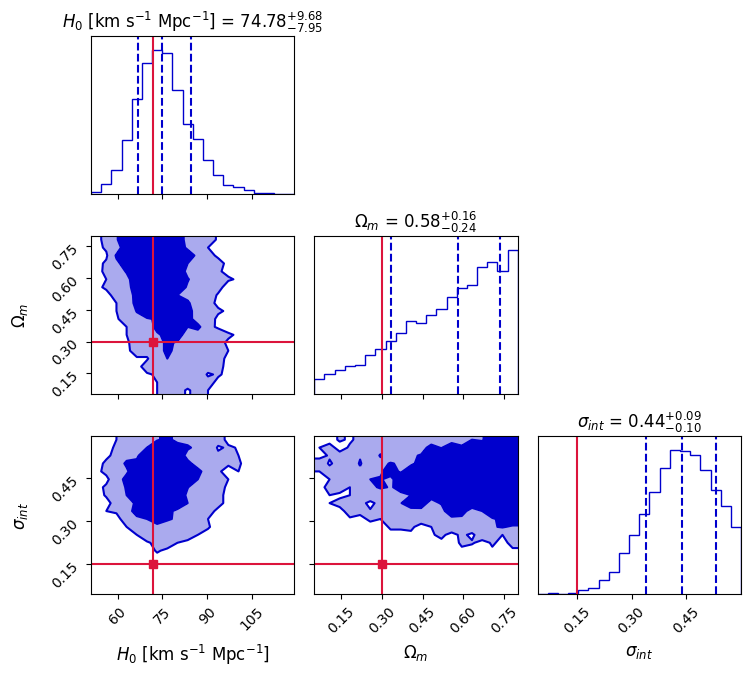

Calculated Beta Corner Plot


<Figure size 800x800 with 0 Axes>

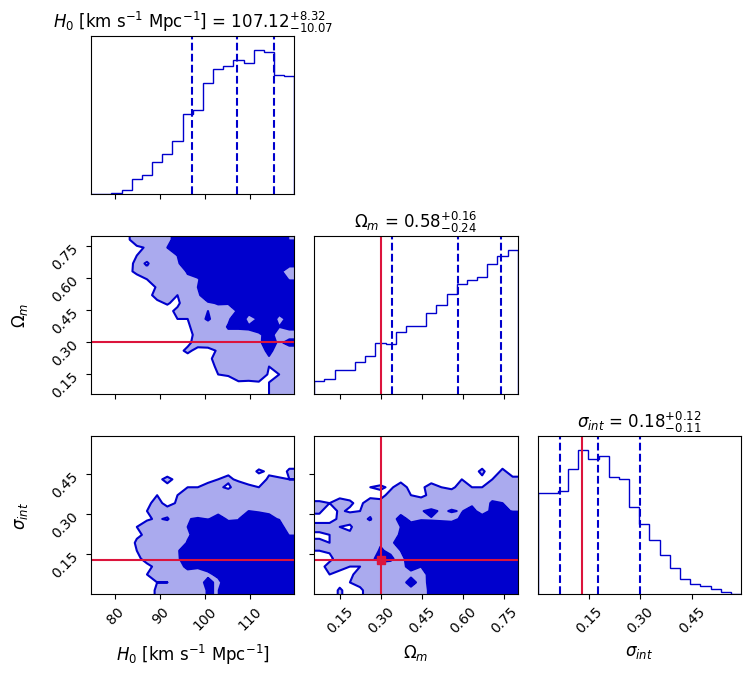

In [ ]:
def run_cluster_mcmc(DA_obs, DA_err, z_vals, model_name):
    print(f"Running MCMC for: {model_name}...")

    z_vals = np.asarray(z)

    def lnlike(theta, z_vals, DA_obs, DA_err):
        H0, omega_m, sigma_int = theta
        cosmo = FlatLambdaCDM(H0=H0, Om0=omega_m)
        DA_model = cosmo.angular_diameter_distance(z_vals).value / 1000 # Gpc
        total_err2 = DA_err**2 + (sigma_int * DA_model)**2
        chi2 = np.sum((DA_obs - DA_model)**2 / total_err2)
        return -0.5 * (chi2 + np.sum(np.log(2 * np.pi * total_err2)))

    def lnprior(theta):
        H0, omega_m, sigma_int = theta
        if 40 < H0 < 120 and 0.05 < omega_m < 0.8 and 0.0 < sigma_int < 0.6:
            return 0.0
        return -np.inf

    def lnprob(theta, z_vals, DA_obs, DA_err):
        lp = lnprior(theta)
        return lp + lnlike(theta, z_vals, DA_obs, DA_err) if np.isfinite(lp) else -np.inf

    ##
    ndim, nwalkers = 3, 16
    initial = np.array([72, 0.3, 0.15])
    pos = initial + 1e-4 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob, args=(z_vals, DA_obs, DA_err))
    sampler.run_mcmc(pos, 5000, progress=True)
    samples = sampler.get_chain(discard=1000, thin=15, flat=True)

    # Print Autocorrelation for convergence proof
    tau = sampler.get_autocorr_time()
    print(f"{model_name} Autocorr times: {tau}")

    return samples

#
samples_iso = run_cluster_mcmc(DA_iso, DA_err_total, z.values, "Isothermal")
samples_calc = run_cluster_mcmc(DA_calc, DA_err_total, z.values, "Calculated Beta")

#
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$\sigma_{int}$"]
ndim = 3

print("Isothermal Model Corner Plot")
plt.figure(figsize=(8, 8))
fig1 = corner.corner(
    samples_iso, labels=labels, truths=[72, 0.3, 0.15],
    show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84],
    levels=(0.68, 0.95), color="mediumblue", truth_color="crimson",
    fill_contours=True, plot_datapoints=False,  label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#
print("Calculated Beta Corner Plot")
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$\sigma_{int}$"]
fig2 = corner.corner(samples_calc, labels=labels, truths=[72, 0.3, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Running MCMC for: Isothermal...


100%|██████████| 5000/5000 [23:21<00:00,  3.57it/s]


Isothermal Autocorr times: [46.89355627 50.96465866 41.96127135]
Running MCMC for: Calculated Beta...


100%|██████████| 5000/5000 [22:41<00:00,  3.67it/s]


Calculated Beta Autocorr times: [66.35706864 62.12844081 43.98456108]
Isothermal Model Corner Plot


<Figure size 800x800 with 0 Axes>

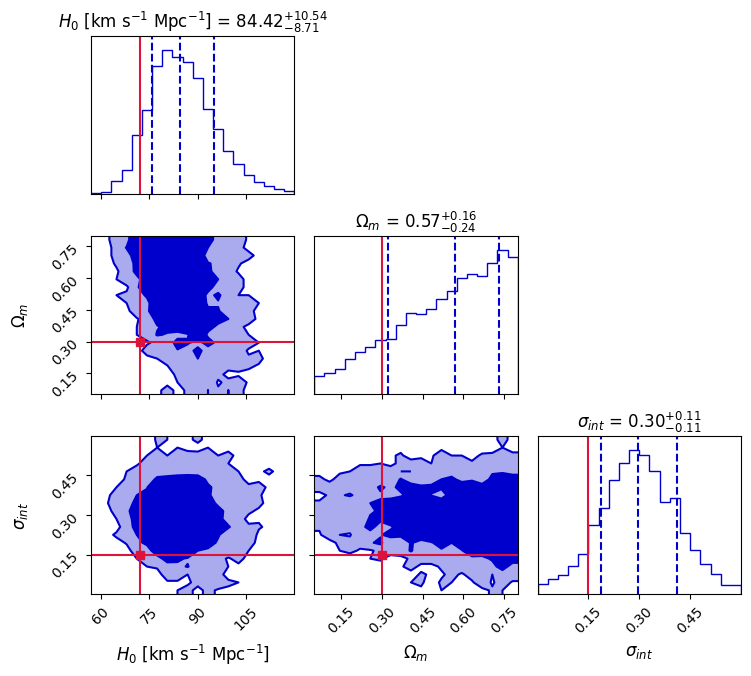

Calculated Beta Corner Plot


<Figure size 800x800 with 0 Axes>

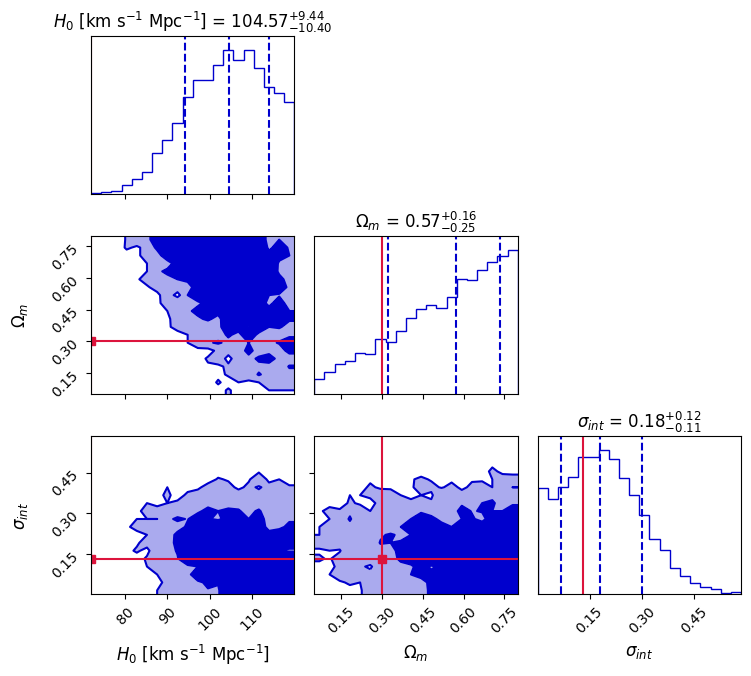

In [ ]:
## We want to see the effect of borderlines clusters
samples_iso_2D = run_cluster_mcmc(DA_iso_normal, DA_err_total, z.values, "Isothermal")
samples_calc_2D = run_cluster_mcmc(DA_calc_2D, DA_err_total, z.values, "Calculated Beta")

#
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$\sigma_{int}$"]
ndim = 3

print("Isothermal Model Corner Plot")
plt.figure(figsize=(8, 8))
fig1 = corner.corner(
    samples_iso_2D, labels=labels, truths=[72, 0.3, 0.15],
    show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84],
    levels=(0.68, 0.95), color="mediumblue", truth_color="crimson",
    fill_contours=True, plot_datapoints=False,  label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#
print("Calculated Beta Corner Plot")
plt.figure(figsize=(8, 8))
labels = [r"$H_0$ [km s$^{-1}$ Mpc$^{-1}$]", r"$\Omega_m$", r"$\sigma_{int}$"]
fig2 = corner.corner(samples_calc_2D, labels=labels, truths=[72, 0.3, 0.13], show_titles=True,
    title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], levels=(0.68, 0.95), color="mediumblue",
    truth_color="crimson", plot_datapoints=False, fill_contours=True, label_kwargs={"fontsize": 12})
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()